# Task 4 - Convolutional autoencoder baseline

## 1. Objective and CAE theory

Preprocessing produced consistent image inputs, but the label structure is still difficult. The catalogue has **249 joint classes**, large visual differences within some classes, and several classes that are too small to form positive pairs. The first experiment asks a simple question: before using the labels, can the images alone produce a useful similarity space? A convolutional autoencoder (CAE) provides that label-free lower bound.

An autoencoder contains an encoder $E$ and a decoder $D$. The encoder compresses image $x$ into latent representation $z=E(x)$, and the decoder reconstructs it as $\hat{x}=D(z)$. Training minimises the pixel reconstruction error

$$\mathcal{L}_{rec}=\frac{1}{N}\sum_i\lVert x_i-\hat{x}_i\rVert_2^2.$$

The bottleneck prevents the network from simply copying every input value and encourages it to retain recurring structure. Convolution is particularly appropriate for images because nearby pixels form local motifs such as edges, textures and garment contours [1]. In this implementation, a from-scratch ResNet-18 produces a `512 × 4 × 4` feature map. Adaptive average pooling converts it into a 512-D L2-normalised retrieval vector, while a transposed-convolution decoder supplies the reconstruction objective. The decoder is a training scaffold; similarity search uses only the encoder vector [2].


### Autoencoder structure

<div align="center"><img src="figures/01_autoencoder_external.png" width="760" alt="General autoencoder structure with encoder, code and decoder"></div>

*Figure 1. A general autoencoder compresses input $x$ into code $z$ and reconstructs output $x'$. Reproduced from [5] under CC BY-SA 4.0.*

The source figure captures the central rule behind the baseline: **the encoder must pass information through a smaller code before the decoder can rebuild the input**. In this Task 4 implementation, that code is the **512-D retrieval embedding**. Reconstruction provides the training signal, but the decoder is removed when products are compared. The next figure connects this general theory to the exact CAE used in the notebook.


### CAE implementation

![Convolutional autoencoder mechanism](figures/01_cae_mechanism.svg)

*Figure 2. The decoder supplies the reconstruction training signal; only the encoder vector is used for cosine retrieval. Original schematic based on the CAE formulation in [1].*


## 2. Model rationale

The catalogue photographs are centred on mostly clean backgrounds, so reconstructing the image should expose the encoder to colour, global outline and texture. The CAE can also learn from every image, including rare classes that cannot form reliable same-class pairs. This makes it a fair test of how much visual structure is available before label supervision is introduced.

At the same time, the model has an important expected limitation. Mean-squared error rewards every reconstructed pixel. A white background, a small logo and a garment outline all affect the loss, even though they are not equally important to the `articleType__gender` relevance rule. The model is therefore selected as an unsupervised baseline, not because reconstruction is assumed to be the final retrieval solution. Its value is that it separates “the images contain useful signal” from “the learning objective organises that signal semantically.”


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from torch import nn
from tqdm.auto import tqdm

from src.task4.config import (
    CAE_BATCH_SIZE,
    CONFIG_DIR,
    EARLY_STOPPING_PATIENCE,
    FINAL_EPOCHS,
    HISTORY_DIR,
    IMAGE_DIR,
    INPUT_SIZE,
    LABEL_COLUMN,
    LABEL_ID_COLUMN,
    MIN_CLASS_SIZE,
    MIN_DELTA,
    MODEL_DIR,
    N_TRIALS,
    PLOT_DIR,
    SEED,
    SPLIT_DIR,
    TUNING_EPOCHS,
    VAL_FRACTION,
)
from src.task4.data import (
    make_evaluation_loader,
    make_training_loader,
)
from src.task4.models import ConvolutionalAutoencoder, ResNet18Encoder
from src.task4.preprocessing import (
    cae_preprocessing_config,
    cae_transform,
)
from src.task4.retrieval import (
    evaluate_retrieval,
    extract_color_descriptors,
    extract_embeddings,
    k_reciprocal_rerank,
    retrieval_metrics,
    search_cosine,
)
from src.task4.training import (
    AMP_ENABLED,
    DEVICE,
    EarlyStopping,
    cpu_state_dict,
    evaluate_loss,
    new_optimizer_and_scheduler,
    set_seed,
    train_one_epoch,
)
from src.task4.tuning import create_study, load_best_params


## 3. Data and validation split
The outer hold-out remains sealed. Joint classes with fewer than five outer-training examples are excluded because they cannot support a stable inner split. The remaining data contain **30,389 training rows** and **3,378 validation rows**. Every later model uses the same seed and split logic.

Tuning evaluates against a 2,861-row gallery capped at 20 items per class. This reduces repeated nearest-neighbour work and prevents large classes from dominating runtime. Final inner-validation retrieval uses the full 30,389-row gallery, so its mAP@10 is **not numerically comparable** with the tuning-gallery score. Unlike the supervised models, the CAE uses ordinary shuffled batches (`batch_size=128`) because reconstruction does not require multiple examples from each class.

> **Reading note.** The approximately 0.147 mAP@10 used during checkpoint selection comes from the capped 2,861-item tuning gallery. The approximately 0.504 value reported at the end uses the full inner-training gallery. They answer different evaluation questions and must not be compared as if one were an improvement during the same run.


In [3]:
set_seed(SEED)
print("Device:", DEVICE, "| Mixed precision:", AMP_ENABLED)


Device: cuda | Mixed precision: True


In [4]:
outer_train_df = pd.read_csv(SPLIT_DIR / "train.csv")
with (CONFIG_DIR / "articleType_gender_label_encoder.json").open(
    encoding="utf-8"
) as file:
    label_encoder_config = json.load(file)

classes = label_encoder_config["classes"]
label_to_index = label_encoder_config["label_to_index"]

outer_train_df[LABEL_COLUMN] = (
    outer_train_df["articleType"].str.strip()
    + "__"
    + outer_train_df["gender"].str.strip()
)

outer_train_df[LABEL_ID_COLUMN] = (
    outer_train_df[LABEL_COLUMN].map(label_to_index).astype("int64")
)

outer_class_counts = outer_train_df[LABEL_COLUMN].value_counts()
eligible_labels = set(outer_class_counts[outer_class_counts >= MIN_CLASS_SIZE].index)
development_df = outer_train_df[
    outer_train_df[LABEL_COLUMN].isin(eligible_labels)
].copy()


In [5]:
inner_stratify_columns = ["articleType", "gender"]
inner_stratify_features = pd.get_dummies(
    development_df[inner_stratify_columns].astype(str),
    prefix=inner_stratify_columns,
)
inner_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=VAL_FRACTION,
    random_state=SEED,
)
inner_train_idx, inner_val_idx = next(
    inner_splitter.split(development_df, inner_stratify_features)
)
train_df = development_df.iloc[inner_train_idx].copy()
val_df = development_df.iloc[inner_val_idx].copy()

train_counts = train_df[LABEL_ID_COLUMN].value_counts()
valid_label_ids = train_counts[train_counts >= MIN_CLASS_SIZE].index
train_df = train_df[train_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()
val_df = val_df[val_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()

overlap = set(train_df["id"]) & set(val_df["id"])
if overlap:
    raise ValueError(f"Inner split contains {len(overlap)} overlapping IDs")
if val_df[LABEL_ID_COLUMN].isna().any():
    raise ValueError("Inner validation contains an unmapped label")


In [6]:
gallery_parts = []
for _, group in train_df.groupby(LABEL_COLUMN, sort=True):
    sample_size = min(20, len(group))
    gallery_parts.append(group.sample(sample_size, random_state=SEED))

tuning_gallery_df = pd.concat(gallery_parts).sort_values("id").reset_index(drop=True)

print(f"Model train/validation: {len(train_df):,}/{len(val_df):,}")
print("Excluded rare rows:", len(outer_train_df) - len(development_df))
print("Tuning gallery rows:", len(tuning_gallery_df))


Model train/validation: 30,389/3,378
Excluded rare rows: 153
Tuning gallery rows: 2861


In [7]:
def make_cae_loaders(train_frame, gallery_frame, query_frame):
    return {
        "train": make_training_loader(train_frame, cae_transform, CAE_BATCH_SIZE, IMAGE_DIR),
        "gallery": make_evaluation_loader(gallery_frame, cae_transform, IMAGE_DIR),
        "query": make_evaluation_loader(query_frame, cae_transform, IMAGE_DIR),
    }

def compute_cae_loss(model, loss_function, batch):
    images = batch["image"].to(DEVICE, non_blocking=True)
    reconstruction, _ = model(images)
    return loss_function(reconstruction, images)


## 4. Hyperparameter tuning
Optuna runs 20 TPE trials for at most 15 epochs and prunes weak trials after a warm-up [4]. The objective is validation mAP@10 rather than reconstruction loss, because retrieval ranking is the actual task.

| Parameter | Search range | Why it is tuned |
|---|---:|---|
| learning rate | `3e-5` to `1e-3` (log) | spans conservative to fast AdamW updates for a from-scratch encoder-decoder |
| weight decay | `1e-6` to `1e-3` (log) | controls overfitting without assuming the same regularisation scale as supervised losses [3] |

Architecture, input size, batch size, augmentation, and evaluation gallery are fixed to keep the small budget interpretable. The saved study selected approximately `lr=8.47e-5` and `weight_decay=7.11e-4`; this is evidence for this split and budget, not a universal optimum.


In [ ]:
def cae_objective(trial: optuna.Trial):
    parameters = {
        "learning_rate": trial.suggest_float("learning_rate", 3e-5, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
    }
    set_seed(SEED)
    model = ConvolutionalAutoencoder(ResNet18Encoder())
    loss_function = nn.MSELoss()
    model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
    loaders = make_cae_loaders(train_df, tuning_gallery_df, val_df)
    optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    best_score = -math.inf
    for epoch in tqdm(range(1, TUNING_EPOCHS + 1), desc="cae tuning"):
        train_one_epoch(
            model, loss_function, compute_cae_loss, loaders["train"], optimizer, scaler, epoch
        )
        score = evaluate_retrieval(model, loaders["gallery"], loaders["query"])[
            "mAP@10"
        ]
        scheduler.step(score)
        best_score = max(best_score, score)
        trial.report(score, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_score

In [ ]:
cae_study = create_study("task4_cae")
cae_study.optimize(cae_objective, n_trials=N_TRIALS)

print("cae", "best parameters:", cae_study.best_params)
print("cae", "tuned validation mAP@10:", cae_study.best_value)


### 4.1 Hyperparameter search results

Figure 3 gives a compact view of how the CAE search progressed and where its stronger settings were found.

- **Optimization history:** tracks the best-so-far validation mAP@10 and retains pruned trials through their final intermediate score.
- **Parameter slice:** positions completed trials by learning rate and weight decay, making the stronger observed configurations easy to identify.


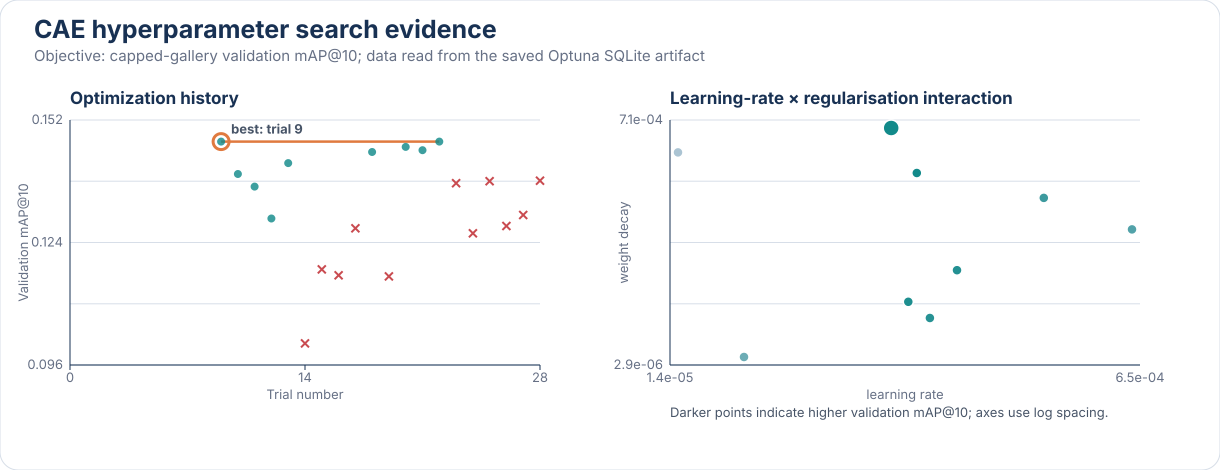

In [1]:
from pathlib import Path
from IPython.display import SVG, display

figure_path = Path("notebooks/task4/figures/01_cae_hpo_evidence.svg")
if not figure_path.exists():
    figure_path = Path("figures/01_cae_hpo_evidence.svg")
display(SVG(filename=str(figure_path)))


*Figure 3. Optimization history and the observed learning-rate/weight-decay interaction, reconstructed directly from the persistent Optuna database.*

The artifact contains **9 completed** and **11 pruned trials**. **Trial 9** produced the highest observed **validation mAP@10 of 0.1473** with **`learning_rate=8.47e-05`** and **`weight_decay=0.000711`**. The orange line shows when Optuna found a better configuration. The right panel keeps every completed trial visible, because this small search is not dense enough to imply a smooth response surface. Darker points mean stronger validation retrieval within this study, so the plot justifies the selected pair without making a causal claim about either parameter.


## 5. Final training and checkpoint selection
The selected parameters are loaded from the persistent Optuna database; the expensive search cell need not be rerun. AdamW updates the model, `ReduceLROnPlateau` halves the learning rate after two stagnant mAP checks, and early stopping allows ten non-improving epochs. The best state is the epoch with highest inner-validation mAP@10, not the last epoch or the lowest MSE.

This distinction matters: reconstruction loss can continue falling while the latent neighbourhood becomes no more useful for semantic retrieval. One fixed seed controls splits and sampling, but CUDA speed settings are not bitwise deterministic; results should therefore be reported as a single-run estimate.


In [8]:
cae_history = []
cae_best_epoch = 0
cae_best_score = -math.inf

cae_best_params, cae_tuning_best_value = load_best_params("task4_cae")
print("cae loaded Optuna best parameters:", cae_best_params)
print("cae tuned validation mAP@10:", cae_tuning_best_value)

parameters = cae_best_params
set_seed(SEED)
model = ConvolutionalAutoencoder(ResNet18Encoder())
loss_function = nn.MSELoss()
model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
loaders = make_cae_loaders(train_df, tuning_gallery_df, val_df)
val_loss_loader = make_evaluation_loader(val_df, cae_transform, IMAGE_DIR)


cae loaded Optuna best parameters: {'learning_rate': 8.468008575248323e-05, 'weight_decay': 0.0007114476009343421}
cae tuned validation mAP@10: 0.14734454845565956


In [9]:
optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
stopper = EarlyStopping(EARLY_STOPPING_PATIENCE, MIN_DELTA)
best_state = None


In [10]:
for epoch in tqdm(range(1, FINAL_EPOCHS + 1), desc="cae final"):
    train_loss = train_one_epoch(
        model, loss_function, compute_cae_loss, loaders["train"], optimizer, scaler, epoch
    )
    val_loss = evaluate_loss(model, loss_function, compute_cae_loss, val_loss_loader)
    metrics = evaluate_retrieval(model, loaders["gallery"], loaders["query"])
    score = metrics["mAP@10"]
    scheduler.step(score)
    if stopper.update(score):
        best_state = cpu_state_dict(model)
        cae_best_epoch = epoch
    cae_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_map_at_10": score,
        }
    )
    print("cae", epoch, "loss:", round(train_loss, 4), "mAP@10:", round(score, 4))
    if stopper.should_stop:
        break


cae final:   0%|          | 0/60 [00:00<?, ?it/s]

cae 1 loss: 0.1112 mAP@10: 0.1189
cae 2 loss: 0.031 mAP@10: 0.1284
cae 3 loss: 0.0136 mAP@10: 0.1319
cae 4 loss: 0.0081 mAP@10: 0.1329
cae 5 loss: 0.0057 mAP@10: 0.1345
cae 6 loss: 0.0043 mAP@10: 0.1368
cae 7 loss: 0.0036 mAP@10: 0.1376
cae 8 loss: 0.0031 mAP@10: 0.138
cae 9 loss: 0.0027 mAP@10: 0.14
cae 10 loss: 0.0025 mAP@10: 0.1415
cae 11 loss: 0.0023 mAP@10: 0.1423
cae 12 loss: 0.0021 mAP@10: 0.1422
cae 13 loss: 0.002 mAP@10: 0.1387
cae 14 loss: 0.0019 mAP@10: 0.1418
cae 15 loss: 0.0018 mAP@10: 0.1449
cae 16 loss: 0.0017 mAP@10: 0.1461
cae 17 loss: 0.0017 mAP@10: 0.1465
cae 18 loss: 0.0016 mAP@10: 0.1463
cae 19 loss: 0.0016 mAP@10: 0.1453
cae 20 loss: 0.0015 mAP@10: 0.144
cae 21 loss: 0.0014 mAP@10: 0.1446
cae 22 loss: 0.0014 mAP@10: 0.1464
cae 23 loss: 0.0014 mAP@10: 0.1446
cae 24 loss: 0.0014 mAP@10: 0.1451
cae 25 loss: 0.0014 mAP@10: 0.1456
cae 26 loss: 0.0013 mAP@10: 0.1456
cae 27 loss: 0.0013 mAP@10: 0.1457


In [11]:
model.load_state_dict(best_state)
cae_best_score = stopper.best_score
cae_model = model
print("cae", "best epoch:", cae_best_epoch, "best mAP@10:", cae_best_score)


cae best epoch: 17 best mAP@10: 0.14651535299995927


## 6. Training curves
Read the left panel as reconstruction fidelity and the right panel as task utility. A falling MSE with flat or falling mAP@10 indicates that the decoder is improving pixel detail without improving semantic neighbours. The saved notebook output peaks at epoch 17 (mAP@10 approximately 0.147 on the capped tuning gallery) and stops after ten further non-improving epochs, which supports early stopping.

**Artifact audit:** the re-uploaded `best.pt` records a slightly different selection score (0.1481), while `cae_history.csv` and `cae_learning_curves.png` are absent. This most likely reflects a later run whose notebook outputs were not saved. Before submission, regenerate or recover those two files, or label the checkpoint as a later run; do not mix the two provenances in one reported result.


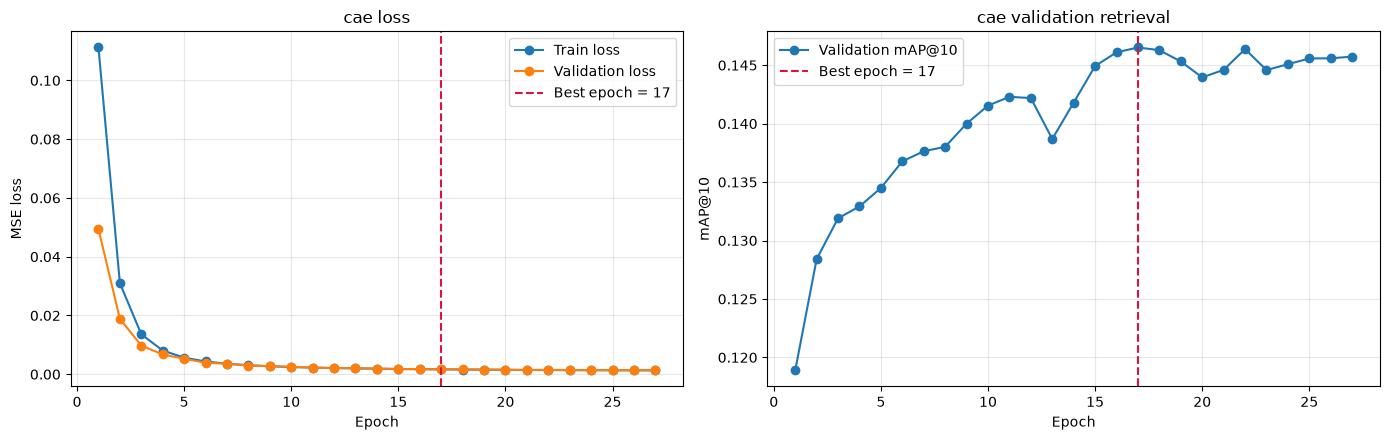

In [12]:
HISTORY_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

history_path = HISTORY_DIR / "cae_history.csv"
pd.DataFrame(cae_history).sort_values("epoch").to_csv(history_path, index=False)
history_df = pd.read_csv(history_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(
    history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss"
)
axes[0].plot(
    history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss"
)
axes[0].axvline(
    cae_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {cae_best_epoch}",
)
axes[0].set_title("cae loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["val_map_at_10"],
    marker="o",
    label="Validation mAP@10",
)
axes[1].axvline(
    cae_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {cae_best_epoch}",
)
axes[1].set_title("cae validation retrieval")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP@10")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(PLOT_DIR / "cae_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Model artifact and inner-validation evaluation
The checkpoint stores weights, architecture, best parameters/epoch, preprocessing, class mapping, seed, and gallery scope. `gallery_embeddings.npy` and `gallery_ids.npy` form the searchable full inner-training gallery. These large artifacts can stay out of Git and be distributed separately, but `06_final_benchmark.ipynb` expects the exact directory `artifacts/task4/models/cae/`.

The saved execution reports raw full-gallery mAP@10 of about **0.504**; the common colour/k-reciprocal reranker reduces it to about **0.492**. The decline is evidence that reranking is not automatically beneficial when the base neighbourhood is weak. It should be reported, not hidden.


In [13]:
model_directory = MODEL_DIR / "cae"
model_directory.mkdir(parents=True, exist_ok=True)
checkpoint = {
    "model_name": "cae",
    "model_state_dict": cpu_state_dict(cae_model),
    "model_config": {
        "backbone": "resnet18",
        "pretrained": False,
        "input_size": list(INPUT_SIZE),
        "embedding_dimension": 512,
        "class_count": len(classes),
    },
    "best_params": cae_best_params,
    "best_epoch": cae_best_epoch,
    "best_val_map_at_10": cae_best_score,
    "preprocessing_config": cae_preprocessing_config,
    "label_to_index": label_to_index,
    "gallery_scope": "eligible_inner_training",
    "random_seed": SEED,
}
torch.save(checkpoint, model_directory / "best.pt")
print("Saved:", model_directory / "best.pt")


Saved: /workspace/Machine-Learning-Assignment-2/artifacts/task4/models/cae/best.pt


In [14]:
gallery_loader = make_evaluation_loader(train_df, cae_transform, IMAGE_DIR)
gallery_embeddings, gallery_ids, gallery_labels = extract_embeddings(
    cae_model, gallery_loader
)
np.save(model_directory / "gallery_embeddings.npy", gallery_embeddings)
np.save(model_directory / "gallery_ids.npy", gallery_ids)


In [16]:
query_loader = make_evaluation_loader(val_df, cae_transform, IMAGE_DIR)
query_embeddings, query_ids, query_labels = extract_embeddings(cae_model, query_loader)


In [17]:
_, base_indices, index = search_cosine(query_embeddings, gallery_embeddings)
query_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in query_ids
)
gallery_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in gallery_ids
)
reranked_indices = k_reciprocal_rerank(
    query_embeddings,
    gallery_embeddings,
    index,
    query_color_descriptors=query_color_descriptors,
    gallery_color_descriptors=gallery_color_descriptors,
    color_weight=0.15,
)
print("cae", "base:", retrieval_metrics(base_indices, query_labels, gallery_labels))
print(
    "cae",
    "reranked:",
    retrieval_metrics(reranked_indices, query_labels, gallery_labels),
)


cae base: {'Precision@1': 0.6903493191237419, 'Recall@1': 0.002767247287802667, 'Precision@5': 0.6236234458259327, 'Recall@5': 0.01041527570733111, 'Precision@10': 0.5844878626406158, 'Recall@10': 0.01779509835577436, 'mAP@10': 0.5038021347279784}
cae reranked: {'Precision@1': 0.5879218472468917, 'Recall@1': 0.0019767679633514793, 'Precision@5': 0.5867377146240379, 'Recall@5': 0.009159801679648902, 'Precision@10': 0.5744819419775016, 'Recall@10': 0.01703522141837461, 'mAP@10': 0.4918319139927093}


## 8. Comparison and transition to Triplet

The following values come from the saved full inner-validation execution with 3,378 queries. The output is an ordered neighbour list, not one predicted class. Precision@K measures how clean the first K results are, Recall@10 measures how much relevant gallery content is recovered, and mAP@10 also rewards correct ordering.

| CAE pipeline | Precision@1 | Precision@5 | Precision@10 | Recall@10 | mAP@10 |
|---|---:|---:|---:|---:|---:|
| raw cosine | **0.6903** | **0.6236** | **0.5845** | **0.0178** | **0.5038** |
| reranked | 0.5879 | 0.5867 | 0.5745 | 0.0170 | 0.4918 |

The raw model retrieves a relevant first item for many queries, which confirms that reconstruction has captured genuine catalogue structure. However, quality falls as the list becomes longer, and reranking reduces mAP@10 from 0.5038 to 0.4918. Colour and reciprocal-neighbour post-processing cannot repair an embedding whose semantic neighbourhood is already mixed.

The saved embedding provides a second view of the same problem. Across 50,000 same-class and 50,000 different-class pairs, mean cosine similarity is 0.9575 and 0.9288 respectively, leaving a mean gap of only 0.0287. More importantly, the robust gap $P10(same)-P90(different)$ is −0.0407. The lower tail of relevant pairs therefore overlaps the upper tail of irrelevant pairs, which explains why plausible-looking reconstructions do not automatically create clean semantic retrieval.

Taken together, the results keep CAE as the label-free baseline but reject it as the final model. The images clearly contain useful signal; the weak separation shows that the loss is not aligned with the relevance definition. The next experiment keeps the same data protocol and 512-D encoder. It changes only the objective: a same-label item should be closer than a different-label item. That is the role of Triplet Margin Loss in `02_triplet_margin.ipynb`.

The CAE history CSV is missing, and the checkpoint score differs slightly from the saved notebook output. These artifact-record differences are reported rather than hidden.


## References

[1] J. Masci, U. Meier, D. Cireşan, and J. Schmidhuber, "Stacked convolutional auto-encoders for hierarchical feature extraction," in *Artificial Neural Networks and Machine Learning - ICANN 2011*, pp. 52-59, doi: [10.1007/978-3-642-21735-7_7](https://doi.org/10.1007/978-3-642-21735-7_7).

[2] K. He, X. Zhang, S. Ren, and J. Sun, "Deep residual learning for image recognition," in *Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2016, pp. 770-778. [Online]. Available: https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html

[3] I. Loshchilov and F. Hutter, "Decoupled weight decay regularization," in *Proc. Int. Conf. Learn. Representations (ICLR)*, 2019. [Online]. Available: https://arxiv.org/abs/1711.05101

[4] T. Akiba, S. Sano, T. Yanase, T. Ohta, and M. Koyama, "Optuna: A next-generation hyperparameter optimization framework," in *Proc. 25th ACM SIGKDD Int. Conf. Knowl. Discov. Data Mining*, 2019, pp. 2623-2631, doi: [10.1145/3292500.3330701](https://doi.org/10.1145/3292500.3330701).

[5] Chervinskii, "Autoencoder structure," *Wikimedia Commons*, Dec. 10, 2015. Licensed under CC BY-SA 4.0. [Online]. Available: https://commons.wikimedia.org/wiki/File:Autoencoder_structure.png
